In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

df = pd.read_csv("heart (1) (1).csv")

X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

# One-Hot Encoding for categorical features
ct = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(drop="first"), categorical_cols)
    ],
    remainder="passthrough"
)

X_encoded = ct.fit_transform(X)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Train Models

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier()
}

print("\n--- Without PCA ---")
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: {acc:.4f}")

# : Apply PCA
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

# Train-test split again
X_train_pca, X_test_pca, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

print("\n--- With PCA ---")
pca_results = {}

for name, model in models.items():
    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred)
    pca_results[name] = acc
    print(f"{name}: {acc:.4f}")

print("\n--- Comparison ---")
for model in models.keys():
    print(f"{model}: Without PCA = {results[model]:.4f}, With PCA = {pca_results[model]:.4f}")

Categorical: Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')
Numerical: Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak'], dtype='object')

--- Without PCA ---
Logistic Regression: 0.8533
SVM: 0.8750
Random Forest: 0.8696

--- With PCA ---
Logistic Regression: 0.8533
SVM: 0.8750
Random Forest: 0.8478

--- Comparison ---
Logistic Regression: Without PCA = 0.8533, With PCA = 0.8533
SVM: Without PCA = 0.8750, With PCA = 0.8750
Random Forest: Without PCA = 0.8696, With PCA = 0.8478


In [ ]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

# Step 2: Load Dataset
# Ensure "heart.csv" is in the same directory as your script
df = pd.read_csv("heart (1) (1).csv")

# Step 3: Separate features and target
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

# Step 4: Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

print("Categorical features:", list(categorical_cols))
print("Numerical features:", list(numerical_cols))

# Step 5: Encoding
# 5a. Label Encoding for the target variable (if it's text like "Yes"/"No")
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 5b. One-Hot Encoding for categorical feature columns
ct = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(drop="first", sparse_output=False), categorical_cols)
    ],
    remainder="passthrough"
)

X_encoded = ct.fit_transform(X)

# Step 6: Scaling
# Important: Scale AFTER encoding so all features are on the same scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# Step 7: Train-Test Split (Without PCA)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42
)

# Step 8: Train Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier(random_state=42)
}

print("\n--- Model Accuracy Without PCA ---")
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: {acc:.4f}")

# Step 9: Apply PCA
# Keep 95% of the variance to reduce dimensions but retain information
pca = PCA(n_components=0.5)
X_pca = pca.fit_transform(X_scaled)

print(f"\nOriginal number of features: {X_scaled.shape[1]}")
print(f"Number of features after PCA: {X_pca.shape[1]}")

# Train-test split again (using the PCA-transformed data)
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y_encoded, test_size=0.2, random_state=42
)

print("\n--- Model Accuracy With PCA ---")
pca_results = {}

for name, model in models.items():
    model.fit(X_train_pca, y_train_pca)
    y_pred_pca = model.predict(X_test_pca)
    acc = accuracy_score(y_test_pca, y_pred_pca)
    pca_results[name] = acc
    print(f"{name}: {acc:.4f}")

# Step 10: Comparison
print("\n--- Final Comparison ---")
for model in models.keys():
    print(f"{model}: Without PCA = {results[model]:.4f} | With PCA = {pca_results[model]:.4f}")

Categorical features: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
Numerical features: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

--- Model Accuracy Without PCA ---
Logistic Regression: 0.8533
SVM: 0.8750
Random Forest: 0.8804

Original number of features: 15
Number of features after PCA: 4

--- Model Accuracy With PCA ---
Logistic Regression: 0.8261
SVM: 0.8370
Random Forest: 0.8370

--- Final Comparison ---
Logistic Regression: Without PCA = 0.8533 | With PCA = 0.8261
SVM: Without PCA = 0.8750 | With PCA = 0.8370
Random Forest: Without PCA = 0.8804 | With PCA = 0.8370


   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2


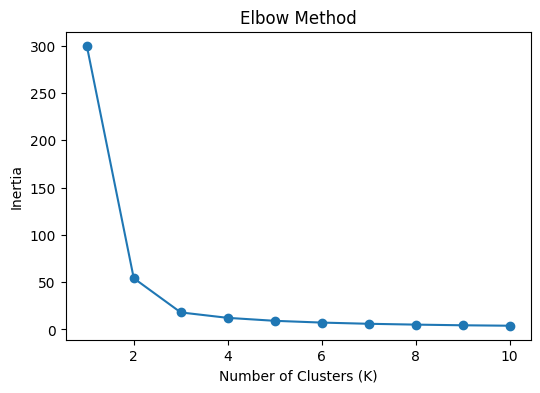

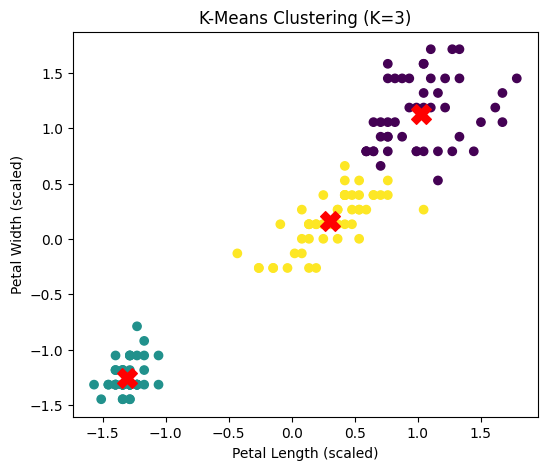

In [ ]:
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Step 2: Load IRIS dataset from sklearn
iris = load_iris()

# Convert to DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Rename columns for simplicity
df.columns = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

print(df.head())

# Step 3: Use only petal features
X = df[["petal_length", "petal_width"]]

# Step 4: Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: Elbow Method
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Step 6: Plot Elbow Curve
plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# Step 7: Optimal K (usually 3)
k_optimal = 3

kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add clusters to dataframe
df["Cluster"] = clusters

# Step 8: Visualization
plt.figure(figsize=(6,5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, cmap='viridis')

# Plot centroids
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200)

plt.xlabel("Petal Length (scaled)")
plt.ylabel("Petal Width (scaled)")
plt.title("K-Means Clustering (K=3)")
plt.show()